ARTI308 - Machine Learning

# Lab 4: Data Preprocessing and PCA — Ames Housing Dataset


In [3]:
# ============================================
# Step 1: Import Required Libraries
# We import libraries for:
# - Data handling (pandas, numpy)
# - Visualization (matplotlib, seaborn)
# - Preprocessing (scalers)
# - Dimensionality Reduction (PCA)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

sns.set(style="whitegrid")

In [4]:
# ============================================
# Step 2: Load the Dataset
# We load the Ames Housing dataset (train.csv)
# This dataset will be used for preprocessing tasks
# ============================================

df = pd.read_csv("train.csv")

# Display first 5 rows
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
# ============================================
# Task 1 - Part A:
# Identify missing values in the dataset
# ============================================

missing_values = df.isna().sum().sort_values(ascending=False)

# Show only columns that have missing values
missing_values[missing_values > 0]

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageQual,81
GarageFinish,81
GarageType,81


In [6]:
# ============================================
# Task 1 - Part B:
# Check if duplicate rows exist
# ============================================

print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [7]:
# ============================================
# Task 1 - Part C:
# Check distribution of data types
# ============================================

df.dtypes.value_counts()

,count
object,43
int64,35
float64,3


In [8]:
# ============================================
# Task 2:
# We apply Median imputation to numerical columns
# Median is chosen because:
# - It is robust to outliers
# - Works better for skewed data like SalePrice
# ============================================

# Select numerical columns
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

# Fill missing numerical values with median
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Verify no missing values remain in numerical columns
df[num_cols].isna().sum().sum()

np.int64(0)

In [9]:
# ============================================
# Task 3:
# Detect outliers using IQR method
# Formula:
# IQR = Q3 - Q1
# Lower Bound = Q1 - 1.5 * IQR
# Upper Bound = Q3 + 1.5 * IQR
# ============================================

Q1 = df["GrLivArea"].quantile(0.25)
Q3 = df["GrLivArea"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Detect outliers
outliers = df[(df["GrLivArea"] < lower_bound) | (df["GrLivArea"] > upper_bound)]

print("Number of outliers detected:", len(outliers))

Number of outliers detected: 31


In [10]:
# ============================================
# Remove detected outliers from dataset
# ============================================

df = df[(df["GrLivArea"] >= lower_bound) & (df["GrLivArea"] <= upper_bound)]

print("Dataset shape after removing outliers:", df.shape)

Dataset shape after removing outliers: (1429, 81)


In [11]:
# ============================================
# Apply Min-Max Scaling
# This scales values between 0 and 1
# ============================================

minmax_scaler = MinMaxScaler()

df_minmax = df.copy()
df_minmax[num_cols] = minmax_scaler.fit_transform(df[num_cols])

df_minmax[num_cols].head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,0.000000,0.235294,0.150685,0.033420,0.666667,0.500,0.949275,0.883333,0.12250,0.322669,...,0.000000,0.116635,0.000000,0.0,0.0,0.0,0.0,0.090909,0.50,0.300993
1,0.000685,0.000000,0.202055,0.038795,0.555556,0.875,0.753623,0.433333,0.00000,0.446984,...,0.347725,0.000000,0.000000,0.0,0.0,0.0,0.0,0.363636,0.25,0.254180
2,0.001371,0.235294,0.160959,0.046507,0.666667,0.500,0.934783,0.866667,0.10125,0.222121,...,0.000000,0.080306,0.000000,0.0,0.0,0.0,0.0,0.727273,0.50,0.327001
3,0.002056,0.294118,0.133562,0.038561,0.666667,0.500,0.311594,0.333333,0.00000,0.098720,...,0.000000,0.066922,0.704663,0.0,0.0,0.0,0.0,0.090909,0.00,0.182226
4,0.002742,0.235294,0.215753,0.060576,0.777778,0.500,0.927536,0.833333,0.21875,0.299360,...,0.224037,0.160612,0.000000,0.0,0.0,0.0,0.0,1.000000,0.50,0.372947


In [12]:
# ============================================
# Apply Z-score Standardization
# After scaling:
# Mean = 0
# Standard Deviation = 1
# ============================================

standard_scaler = StandardScaler()

df_zscore = df.copy()
df_zscore[num_cols] = standard_scaler.fit_transform(df[num_cols])

df_zscore[num_cols].head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,-1.726883,0.076225,-0.205480,-0.191357,0.701469,-0.517421,1.058189,0.885988,0.579914,0.634065,...,-0.746583,0.255254,-0.363313,-0.117612,-0.271111,-0.045633,-0.084842,-1.602807,0.136429,0.446248
1,-1.724510,-0.863803,0.526766,-0.074428,-0.040499,2.204276,0.156429,-0.416957,-0.576932,1.269046,...,1.664726,-0.720677,-0.363313,-0.117612,-0.271111,-0.045633,-0.084842,-0.494722,-0.616300,0.067190
2,-1.722137,0.076225,-0.059031,0.093339,0.701469,-0.517421,0.991392,0.837731,0.379237,0.120477,...,-0.746583,-0.048724,-0.363313,-0.117612,-0.271111,-0.045633,-0.084842,0.982724,0.136429,0.656836
3,-1.719764,0.311232,-0.449562,-0.079512,0.701469,-0.517421,-1.880882,-0.706501,-0.576932,-0.509835,...,-0.746583,-0.160717,4.222053,-0.117612,-0.271111,-0.045633,-0.084842,-1.602807,-1.369029,-0.515436
4,-1.717391,0.076225,0.722032,0.399387,1.443437,-0.517421,0.957994,0.741216,1.488864,0.515006,...,0.807012,0.623229,-0.363313,-0.117612,-0.271111,-0.045633,-0.084842,2.090809,0.136429,1.028874


In [13]:
# ============================================
# PCA requires numerical standardized data
# We use the Z-score normalized dataset
# ============================================

X = df_zscore[num_cols]

In [14]:
# ============================================
# Apply PCA on standardized numerical data
# ============================================

pca = PCA()
X_pca = pca.fit_transform(X)

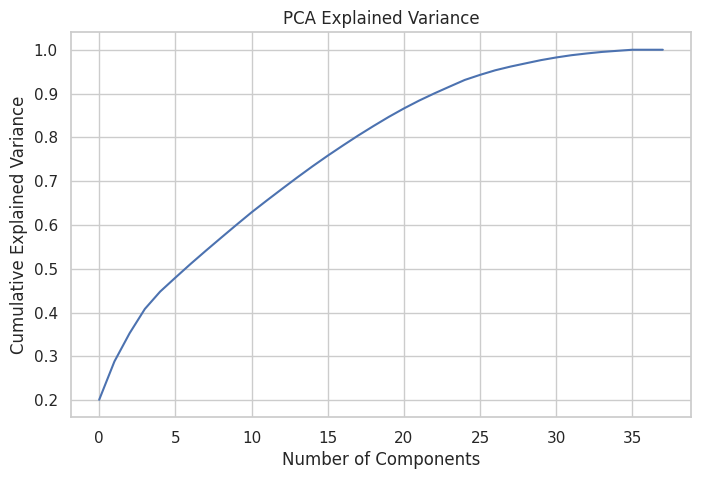

In [15]:
# ============================================
# Plot cumulative explained variance
# This shows how many components retain most variance
# ============================================

explained_variance = pca.explained_variance_ratio_

plt.figure(figsize=(8,5))
plt.plot(np.cumsum(explained_variance))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()

## Conclusion

In this lab:

- Data quality issues were identified.
- Missing values were handled using median imputation.
- Outliers were detected and removed using the IQR method.
- Numerical features were normalized using Min-Max and Z-score techniques.
- PCA was applied and explained variance was analyzed.

End of Lab 4.